# Crescendo Probe Analysis

This notebook studies how Llama-3.1-8B-Instruct internally represents jailbroken Crescendo conversations. 

The main question is whether the model's representation of a harmful final response shifts toward the benign region as the Crescendo conversation grows and whether that shift can be detected and measured with a probe trained on single-turn data.

We run two probes. The first replicates the paper's methodology exactly: an MLP trained on external single-turn harmful and benign data and applied out-of-distribution to Crescendo trajectories. The second is an alternative trained directly on Crescendo conversations, which asks whether harmful and benign Crescendo conversations are linearly separable at all, and whether that separation is stable from the first turn or accumulates with context. Both probes are also compared against a LAT reading vector derived from the pairing structure of the dataset.

In [22]:
import sys, json, random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight

repo_root     = Path('..').resolve()
sys.path.insert(0, str(repo_root))

CRESCENDO_DIR = repo_root / 'datasets' / 'llm_lat_dataset'
ST_PROBE_DIR  = repo_root / 'datasets' / 'single_turn_probe'
RESULTS_DIR   = repo_root / 'results' / 'probe_analysis'

for d in [ST_PROBE_DIR / 'hidden_states', RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LAYERS        = [20, 31]
PRIMARY_LAYER = 31
N_SAMPLES     = 2400  # per class for D_cb + D_r; matches paper
SEED          = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Crescendo data: {CRESCENDO_DIR}')
print(f'ST probe cache: {ST_PROBE_DIR}')
print(f'Results:        {RESULTS_DIR}')

Crescendo data: /Users/lisahusieva/Desktop/multi-turn-research-jam/datasets/llm_lat_dataset
ST probe cache: /Users/lisahusieva/Desktop/multi-turn-research-jam/datasets/single_turn_probe
Results:        /Users/lisahusieva/Desktop/multi-turn-research-jam/results/probe_analysis


## Load model

The single-turn probe (Part 1) needs the model to run forward passes on the D_cb and D_r pairs.
The multi-turn probe (Part 2) and LAT analysis (Part 3) do not require the model directly, since the Crescendo hidden states were already extracted during dataset collection.

In [23]:
from dotenv import load_dotenv
load_dotenv(repo_root / '.env')

from pyrit.setup import initialize_pyrit_async
from src.targets import build_target

await initialize_pyrit_async(memory_db_type='InMemory')
target    = build_target('llama-3.1-8b-local')
model     = target._model
tokenizer = target._tokenizer
device    = target._device

print(f'Model loaded on {device}')

No default environment files found. Using system environment variables only.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded on mps


## Generated LLM-LAT Crescendo dataset

We load the LLM-LAT Crescendo dataset: 100 harmful/benign objective pairs each run through the Crescendo multi-turn jailbreak three times, targeting Llama-3.1-8B-Instruct. For each conversation, hidden states were extracted at every context window size, ranging from the minimal case (only the final prompt-response pair) up to the full conversation. At each context size, the hidden states of the final response tokens were extracted and mean-pooled into a single 4096-dimensional vector. This was done at both layer 31 (the final transformer layer, used as the primary layer following the paper) and layer 20 (a mid-network layer where circuit breakers were inserted in the hardened model variant).

In [24]:
conversations = {
    r['id']: r
    for r in [
        json.loads(l)
        for l in (CRESCENDO_DIR / 'conversations.jsonl').read_text().splitlines()
        if l.strip()
    ]
}
reprs = [
    json.loads(l)
    for l in (CRESCENDO_DIR / 'representations.jsonl').read_text().splitlines()
    if l.strip()
]

verdict_dist = Counter(c['verdict'] for c in conversations.values())
print(f'Conversations: {len(conversations)}  {dict(verdict_dist)}')
print(f'Representations: {len(reprs)}')
print(f'Layers present: {sorted(set(r["layer"] for r in reprs))}')

Conversations: 600  {'Benign': 300, 'Jailbroken': 247, 'Refusal': 53}
Representations: 4932
Layers present: [20, 31]


In [25]:
LAYER = PRIMARY_LAYER

cr_cache: dict[str, np.ndarray] = {}
missing = 0
for r in tqdm(reprs, desc='Loading Crescendo hidden states'):
    path = str(CRESCENDO_DIR / r['mean_pooled_path'])
    if Path(path).exists():
        cr_cache[path] = np.load(path).astype(np.float32)
    else:
        missing += 1

def get_cr_vec(r: dict) -> np.ndarray:
    return cr_cache[str(CRESCENDO_DIR / r['mean_pooled_path'])]

def get_verdict_label(r: dict):
    v = r['verdict']
    if v in ('Jailbroken', 'Near-Miss'): return 1
    if v == 'Benign': return 0
    return None

def safe_auc(pos, neg):
    y = np.array([1]*len(pos) + [0]*len(neg))
    p = np.array(pos + neg)
    return roc_auc_score(y, p) if len(np.unique(y)) > 1 else float('nan')

def plot_traj(ax, traj_dict, color, title, p_fn):
    all_scores = defaultdict(list)
    for records in traj_dict.values():
        ks     = [r['k'] for r in records]
        scores = [p_fn(get_cr_vec(r)) for r in records]
        ax.plot(ks, scores, color=color, alpha=0.2, linewidth=0.8)
        for k, s in zip(ks, scores):
            all_scores[k].append(s)
    sorted_ks = sorted(all_scores)
    means = [np.mean(all_scores[k]) for k in sorted_ks]
    ax.plot(sorted_ks, means, color=color, linewidth=2.5, label='mean')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Turn (k)')
    ax.set_ylabel('P(harmful)')
    ax.set_title(title)
    ax.legend()

print(f'Loaded {len(cr_cache)} arrays, {missing} missing')

Loading Crescendo hidden states:   0%|          | 0/4932 [00:00<?, ?it/s]

Loaded 4932 arrays, 0 missing


---
## Part 1 — Single-turn probe (paper's methodology)

This part replicates the probe methodology from Bullwinkel et al. (2025). The probe is trained on two external datasets that have nothing to do with Crescendo. The harmful class (D_cb) comes from the circuit breakers training set — explicit harmful completions, the kind of text a model would produce without any safety training. The benign class (D_r) comes from ultrachat, an ordinary helpful assistant conversation dataset. The probe learns to distinguish these two distributions. It is then applied, out-of-distribution, to the Crescendo dataset.

No generation is needed for the forward passes. We already have the (prompt, response) pairs from D_cb and D_r, so we concatenate them and run a single forward pass to extract hidden states at the response token positions. A teacher-forced forward pass produces identical hidden states to autoregressive generation, because a causal transformer attends only to preceding tokens regardless of whether those tokens were produced by the model or supplied externally.

This probe never sees any Crescendo data during training. Because D_cb and D_r are completely separate datasets, all 600 Crescendo conversations are held out.

### 1a — D_cb: harmful representations

We sample 2400 records from circuit_breakers_train.json and run a forward pass through the model for each one. The forward pass concatenates the prompt and response using the model's chat template, then extracts hidden states at the response token positions only — the same slice used for Crescendo representations.

In [26]:
def extract_repr_from_pair(prompt_text, response_text, layers):
    messages   = [{'role': 'user', 'content': prompt_text}]
    prompt_ids = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors='pt')
    if hasattr(prompt_ids, 'input_ids'):
        prompt_ids = prompt_ids.input_ids
    response_ids = tokenizer(response_text, return_tensors='pt', add_special_tokens=False).input_ids
    if response_ids.shape[1] == 0:
        return None, 0
    if response_ids.shape[1] > 512:
        response_ids = response_ids[:, :512]
    full_ids   = torch.cat([prompt_ids, response_ids], dim=1).to(device)
    prompt_len = prompt_ids.shape[1]
    with torch.no_grad():
        out = model(full_ids, output_hidden_states=True)
    results = {}
    for layer_idx in layers:
        hs      = out.hidden_states[layer_idx + 1]
        resp_hs = hs[0, prompt_len:, :]
        results[layer_idx] = {
            'mean_pooled': resp_hs.mean(dim=0).cpu().float().numpy(),
            'per_token':   resp_hs.cpu().float().numpy(),
        }
    return results, response_ids.shape[1]

cb_raw    = json.loads((repo_root / 'data' / 'circuit_breakers_train.json').read_text())
cb_raw    = [d for d in cb_raw if d.get('output', '').strip()]
cb_sample = random.sample(cb_raw, min(N_SAMPLES, len(cb_raw)))
print(f'D_cb: {len(cb_raw)} total, sampling {len(cb_sample)}')

hs_dir     = ST_PROBE_DIR / 'hidden_states'
cb_records = []

for i, item in enumerate(tqdm(cb_sample, desc='D_cb forward passes')):
    sid       = f'cb_{i:04d}'
    meta_path = ST_PROBE_DIR / f'{sid}.json'
    m_paths   = {l: hs_dir / f'{sid}_l{l}_mean.npy' for l in LAYERS}
    t_paths   = {l: hs_dir / f'{sid}_l{l}_tokens.npy' for l in LAYERS}

    if meta_path.exists() and all(m_paths[l].exists() for l in LAYERS):
        n_tok = json.loads(meta_path.read_text())['n_response_tokens']
        for l in LAYERS:
            cb_records.append({'id': sid, 'pool': 'harmful', 'layer': l,
                                'n_response_tokens': n_tok,
                                'mean_pooled_path': str(m_paths[l].relative_to(ST_PROBE_DIR))})
        continue

    res, n_tok = extract_repr_from_pair(item['prompt'], item['output'], LAYERS)
    if res is None:
        continue
    meta_path.write_text(json.dumps({'id': sid, 'pool': 'harmful',
                                      'n_response_tokens': n_tok,
                                      'category': item.get('category', '')}))
    for l, arrays in res.items():
        np.save(m_paths[l], arrays['mean_pooled'])
        np.save(t_paths[l], arrays['per_token'])
        cb_records.append({'id': sid, 'pool': 'harmful', 'layer': l,
                            'n_response_tokens': n_tok,
                            'mean_pooled_path': str(m_paths[l].relative_to(ST_PROBE_DIR))})

print(f'D_cb records: {len(cb_records)}')

D_cb: 4994 total, sampling 2400


D_cb forward passes:   0%|          | 0/2400 [00:00<?, ?it/s]

D_cb records: 4800


### 1b — D_r: benign representations

We sample 2400 conversations from the ultrachat_200k test_sft split and use the first user-assistant turn from each. This matches the paper's training data source. Together with D_cb, this gives 4800 training examples evenly balanced between harmful and benign.

In [27]:
from datasets import load_dataset

ultrachat     = load_dataset('HuggingFaceH4/ultrachat_200k', split='test_sft')
retain_pairs  = []
for row in ultrachat:
    msgs = row['messages']
    for i, m in enumerate(msgs):
        if m['role'] == 'user' and i + 1 < len(msgs) and msgs[i+1]['role'] == 'assistant':
            retain_pairs.append({'prompt': m['content'], 'response': msgs[i+1]['content']})
            break

dr_sample  = random.sample(retain_pairs, min(N_SAMPLES, len(retain_pairs)))
print(f'D_r: {len(retain_pairs)} available, sampling {len(dr_sample)}')

dr_records = []
for i, item in enumerate(tqdm(dr_sample, desc='D_r forward passes')):
    sid       = f'dr_{i:04d}'
    meta_path = ST_PROBE_DIR / f'{sid}.json'
    m_paths   = {l: hs_dir / f'{sid}_l{l}_mean.npy' for l in LAYERS}
    t_paths   = {l: hs_dir / f'{sid}_l{l}_tokens.npy' for l in LAYERS}

    if meta_path.exists() and all(m_paths[l].exists() for l in LAYERS):
        n_tok = json.loads(meta_path.read_text())['n_response_tokens']
        for l in LAYERS:
            dr_records.append({'id': sid, 'pool': 'benign', 'layer': l,
                                'n_response_tokens': n_tok,
                                'mean_pooled_path': str(m_paths[l].relative_to(ST_PROBE_DIR))})
        continue

    res, n_tok = extract_repr_from_pair(item['prompt'], item['response'], LAYERS)
    if res is None:
        continue
    meta_path.write_text(json.dumps({'id': sid, 'pool': 'benign', 'n_response_tokens': n_tok}))
    for l, arrays in res.items():
        np.save(m_paths[l], arrays['mean_pooled'])
        np.save(t_paths[l], arrays['per_token'])
        dr_records.append({'id': sid, 'pool': 'benign', 'layer': l,
                            'n_response_tokens': n_tok,
                            'mean_pooled_path': str(m_paths[l].relative_to(ST_PROBE_DIR))})

all_st_records = cb_records + dr_records
(ST_PROBE_DIR / 'representations.jsonl').write_text(
    '\n'.join(json.dumps(r) for r in all_st_records)
)
print(f'D_r records: {len(dr_records)} | Total: {len(all_st_records)}')

D_r: 23110 available, sampling 2400


D_r forward passes:   0%|          | 0/2400 [00:00<?, ?it/s]

D_r records: 4800 | Total: 9600


### 1c — Train single-turn probe

We first run 5-fold stratified cross-validation on the D_cb + D_r data as a sanity check. This tells us whether the MLP can separate these two distributions at all, and whether the result is consistent across folds. A high and stable CV AUC (low standard deviation) means the probe has learned a reliable boundary in the D_cb/D_r space. If CV AUC were low, the rest of the analysis would be uninterpretable, so this is a prerequisite check before applying the probe anywhere else.

After the sanity check, we train a final probe on all 4800 D_cb + D_r examples with balanced sample weights. There is no train/test split within D_cb/D_r needed here: the entire point of this probe is to apply it to Crescendo, which is a completely separate dataset. Crescendo conversations never appear in training, so there is no leakage. Training on all available D_cb/D_r data gives the probe the strongest possible foundation before we ask it to generalize.

In [28]:
st_cache: dict[str, np.ndarray] = {}
for r in all_st_records:
    path = str(ST_PROBE_DIR / r['mean_pooled_path'])
    if Path(path).exists():
        st_cache[path] = np.load(path).astype(np.float32)

def get_st_vec(r): return st_cache[str(ST_PROBE_DIR / r['mean_pooled_path'])]

st_recs = [r for r in all_st_records
           if r['layer'] == LAYER and str(ST_PROBE_DIR / r['mean_pooled_path']) in st_cache]
X_st    = np.stack([get_st_vec(r) for r in st_recs])
y_st    = np.array([1 if r['pool'] == 'harmful' else 0 for r in st_recs])

print(f'D_cb + D_r (layer {LAYER}): n={len(X_st)}, harmful={y_st.sum()}, benign={(y_st==0).sum()}')

cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
st_cv_aucs = []
for tr, te in cv.split(X_st, y_st):
    sc  = StandardScaler()
    sw  = compute_sample_weight('balanced', y_st[tr])
    clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED, early_stopping=True)
    clf.fit(sc.fit_transform(X_st[tr]), y_st[tr], sample_weight=sw)
    st_cv_aucs.append(roc_auc_score(y_st[te], clf.predict_proba(sc.transform(X_st[te]))[:, 1]))

print(f'Sanity check — CV AUC on D_cb vs D_r: {np.mean(st_cv_aucs):.3f} +/- {np.std(st_cv_aucs):.3f}')

st_scaler = StandardScaler()
sw_all    = compute_sample_weight('balanced', y_st)
st_probe  = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED)
st_probe.fit(st_scaler.fit_transform(X_st), y_st, sample_weight=sw_all)

def st_p_harmful(v: np.ndarray) -> float:
    return float(st_probe.predict_proba(st_scaler.transform(v.reshape(1, -1)))[0][1])

print('Single-turn probe trained. All Crescendo conversations are held-out.')

D_cb + D_r (layer 31): n=4800, harmful=2400, benign=2400
Sanity check — CV AUC on D_cb vs D_r: 0.999 +/- 0.001
Single-turn probe trained. All Crescendo conversations are held-out.


### 1d — Apply to Crescendo trajectories

We now apply the single-turn probe to every representation in the Crescendo dataset, producing a harmful probability score for each turn of each conversation. The primary diagnostic is comparing the probe's AUC when only the final turn is included as context against its AUC when the full conversation is included. If the probe can already separate jailbroken from benign conversations using only the final turn, before any prior Crescendo context has accumulated, it means the probe is detecting something static — most likely the topic or objective domain of the conversation — rather than anything about how the jailbreak unfolds across turns. In that case, the trajectory across turns would be uninterpretable as evidence of representational drift.

We also compute the mean harmful probability trajectory for jailbroken and benign conversations separately, and measure drift: the change in mean score for jailbroken conversations from the first turn to the last. A decrease in harmful probability as context grows would replicate the paper's central finding. Refusals are scored separately to assess whether the probe distinguishes between a model that generated harmful content and one that refused — both occurred in the context of the same harmful objectives.

In [29]:
cr_layer_all = [r for r in reprs if r['layer'] == LAYER
                and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]

st_jailbroken: dict[str, list] = defaultdict(list)
st_benign:     dict[str, list] = defaultdict(list)
st_refusal:    dict[str, list] = defaultdict(list)

for r in cr_layer_all:
    v = r['verdict']
    if v in ('Jailbroken', 'Near-Miss'): st_jailbroken[r['id']].append(r)
    elif v == 'Benign':                  st_benign[r['id']].append(r)
    elif v == 'Refusal':                 st_refusal[r['id']].append(r)

for d in (st_jailbroken, st_benign, st_refusal):
    for key in d: d[key].sort(key=lambda r: r['k'])

print(f'Crescendo trajectories: jailbroken={len(st_jailbroken)}, benign={len(st_benign)}, refusal={len(st_refusal)}')

s_jb_k1   = [st_p_harmful(get_cr_vec(min(recs, key=lambda r: r['k']))) for recs in st_jailbroken.values()]
s_bn_k1   = [st_p_harmful(get_cr_vec(min(recs, key=lambda r: r['k']))) for recs in st_benign.values()]
s_jb_kmax = [st_p_harmful(get_cr_vec(max(recs, key=lambda r: r['k']))) for recs in st_jailbroken.values()]
s_bn_kmax = [st_p_harmful(get_cr_vec(max(recs, key=lambda r: r['k']))) for recs in st_benign.values()]

st_auc_k1   = safe_auc(s_jb_k1,   s_bn_k1)
st_auc_kmax = safe_auc(s_jb_kmax, s_bn_kmax)

print(f'\nSingle-turn probe on Crescendo (layer {LAYER}):')
print(f'  AUC at k=1:    {st_auc_k1:.3f}')
print(f'  AUC at k=kmax: {st_auc_kmax:.3f}')
print(f'  Mean P(harmful) — Jailbroken:  k=1 {np.mean(s_jb_k1):.3f}  k=kmax {np.mean(s_jb_kmax):.3f}')
print(f'  Mean P(harmful) — Benign:      k=1 {np.mean(s_bn_k1):.3f}  k=kmax {np.mean(s_bn_kmax):.3f}')

drift = np.mean(s_jb_k1) - np.mean(s_jb_kmax)
if drift > 0.05:
    print(f'\n  Jailbroken P(harmful) decreases {drift:.3f} from k=1 to k=kmax — consistent with Bullwinkel et al.')
elif drift < -0.05:
    print(f'\n  Jailbroken P(harmful) increases {abs(drift):.3f} — inconsistent with paper.')
else:
    print(f'\n  No clear drift ({drift:.3f}). Probe not sensitive to Crescendo context on this dataset.')

Crescendo trajectories: jailbroken=247, benign=300, refusal=53

Single-turn probe on Crescendo (layer 31):
  AUC at k=1:    0.837
  AUC at k=kmax: 0.806
  Mean P(harmful) — Jailbroken:  k=1 0.741  k=kmax 0.683
  Mean P(harmful) — Benign:      k=1 0.230  k=kmax 0.216

  Jailbroken P(harmful) decreases 0.059 from k=1 to k=kmax — consistent with Bullwinkel et al.


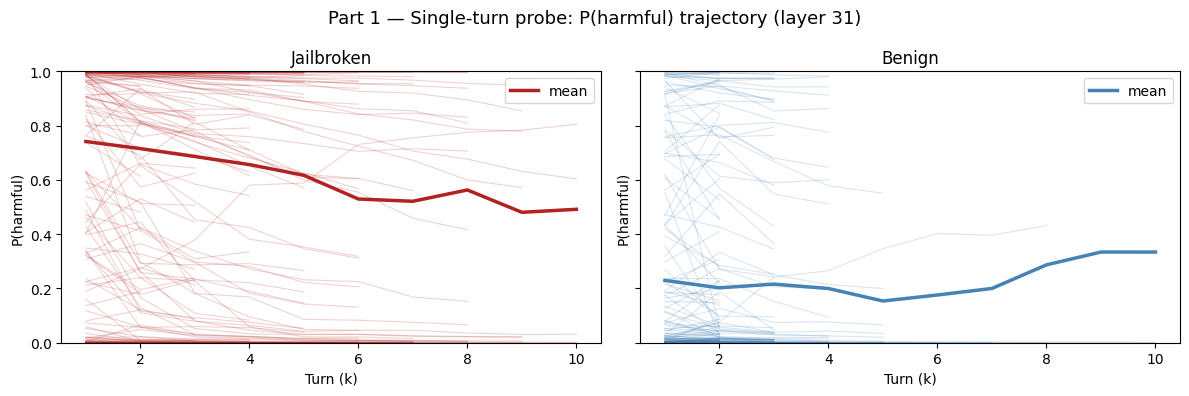

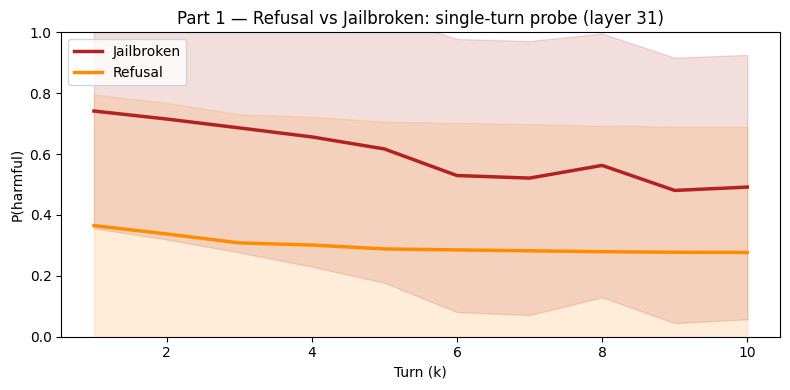

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_traj(axes[0], st_jailbroken, 'firebrick', 'Jailbroken', st_p_harmful)
plot_traj(axes[1], st_benign,     'steelblue', 'Benign',     st_p_harmful)
fig.suptitle(f'Part 1 — Single-turn probe: P(harmful) trajectory (layer {LAYER})', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'st_trajectory_l{LAYER}.png', dpi=150)
plt.show()

# Refusal vs Jailbroken
fig, ax = plt.subplots(figsize=(8, 4))
for traj_dict, color, label in [(st_jailbroken, 'firebrick', 'Jailbroken'),
                                  (st_refusal,    'darkorange', 'Refusal')]:
    if not traj_dict: continue
    all_scores = defaultdict(list)
    for records in traj_dict.values():
        for r in records:
            all_scores[r['k']].append(st_p_harmful(get_cr_vec(r)))
    sorted_ks = sorted(all_scores)
    means = [np.mean(all_scores[k]) for k in sorted_ks]
    stds  = [np.std(all_scores[k])  for k in sorted_ks]
    ax.plot(sorted_ks, means, color=color, linewidth=2.5, label=label)
    ax.fill_between(sorted_ks, [m-s for m, s in zip(means, stds)],
                               [m+s for m, s in zip(means, stds)], color=color, alpha=0.15)
ax.set_ylim(0, 1); ax.set_xlabel('Turn (k)'); ax.set_ylabel('P(harmful)')
ax.set_title(f'Part 1 — Refusal vs Jailbroken: single-turn probe (layer {LAYER})')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / f'st_refusal_vs_jailbreak_l{LAYER}.png', dpi=150)
plt.show()

---
## Part 2 — Multi-turn probe (trained on generated LLM-LAT-Crescendo dataset)

The single-turn probe asks how Crescendo representations look from the perspective of a probe calibrated on a different distribution. This part asks a more direct question: within the LLM-LAT Crescendo dataset itself, are harmful and benign conversations separable at all in representation space?

The probe here is trained on full-context representations from the Crescendo dataset, with conversations split 80/20 at the conversation level. The split is stratified by verdict so that both the training and test splits have the same proportion of jailbroken and benign conversations. Refusals are excluded from training entirely and added to the test set, where they serve as a diagnostic group. All trajectory analysis and plot generation use only the held-out test conversations. 

Class imbalance in the training set (more benign conversations than jailbroken) is corrected with balanced sample weights, which reweight each training example so that both classes contribute equally to the loss. MLPClassifier does not accept a class_weight parameter directly, so compute_sample_weight is used and the weights are passed to fit().

The key diagnostic in this part is the single-turn AUC on the held-out test set. If the probe trained on full-context representations achieves near-identical AUC when only the final turn is provided, it means the probe has learned a signal that is already fully present before any Crescendo escalation has occurred. That would point to the probe detecting the objective domain — this conversation is about a harmful topic — rather than anything about how the jailbreak progresses.

In [41]:
probe_conv_ids = [cid for cid, c in conversations.items()
                  if c['verdict'] in ('Jailbroken', 'Near-Miss', 'Benign')]
probe_strata   = ['Jailbroken' if conversations[cid]['verdict'] in ('Jailbroken', 'Near-Miss') else 'Benign'
                  for cid in probe_conv_ids]

train_ids_list, test_ids_list = train_test_split(
    probe_conv_ids, test_size=0.2, stratify=probe_strata, random_state=SEED
)
train_ids = set(train_ids_list)
test_ids  = set(test_ids_list)
test_ids |= {cid for cid, c in conversations.items() if c['verdict'] == 'Refusal'}

train_v = Counter(conversations[cid]['verdict'] for cid in train_ids)
test_v  = Counter(conversations[cid]['verdict'] for cid in test_ids)
print(f'Train: {len(train_ids)}  {dict(train_v)}')
print(f'Test:  {len(test_ids)}   {dict(test_v)}')

Train: 437  {'Jailbroken': 197, 'Benign': 240}
Test:  163   {'Jailbroken': 50, 'Benign': 60, 'Refusal': 53}


In [42]:
full_ctx   = [r for r in reprs
              if r['layer'] == LAYER and r['k'] == r['k_max']
              and get_verdict_label(r) is not None
              and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]

train_ctx  = [r for r in full_ctx if r['id'] in train_ids]
X_train    = np.stack([get_cr_vec(r) for r in train_ctx])
y_train    = np.array([get_verdict_label(r) for r in train_ctx])

print(f'Train set (layer {LAYER}, k=k_max): n={len(X_train)}, harmful={y_train.sum()}, benign={(y_train==0).sum()}')

sw_train  = compute_sample_weight('balanced', y_train)
mt_scaler = StandardScaler()
mt_probe  = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED)
mt_probe.fit(mt_scaler.fit_transform(X_train), y_train, sample_weight=sw_train)

def mt_p_harmful(v: np.ndarray) -> float:
    return float(mt_probe.predict_proba(mt_scaler.transform(v.reshape(1, -1)))[0][1])

print('Multi-turn probe trained.')

Train set (layer 31, k=k_max): n=437, harmful=197, benign=240
Multi-turn probe trained.


In [33]:
# Test AUC at k=kmax
test_ctx    = [r for r in full_ctx if r['id'] in test_ids]
X_test      = np.stack([get_cr_vec(r) for r in test_ctx])
y_test      = np.array([get_verdict_label(r) for r in test_ctx])
mt_test_auc = roc_auc_score(y_test, mt_probe.predict_proba(mt_scaler.transform(X_test))[:, 1])
print(f'Multi-turn probe — test AUC at k=k_max: {mt_test_auc:.3f}  [{"PASS" if mt_test_auc > 0.85 else "FAIL"}]')
print()

# Diagnostic: k=1 AUC on held-out test set
k1_harmful, k1_benign = [], []
for r in reprs:
    if r['layer'] != LAYER or r['k'] != 1 or r['id'] not in test_ids: continue
    if str(CRESCENDO_DIR / r['mean_pooled_path']) not in cr_cache: continue
    if r['verdict'] in ('Jailbroken', 'Near-Miss'): k1_harmful.append(get_cr_vec(r))
    elif r['verdict'] == 'Benign':                  k1_benign.append(get_cr_vec(r))

mt_auc_k1 = safe_auc([mt_p_harmful(v) for v in k1_harmful],
                     [mt_p_harmful(v) for v in k1_benign])

print(f'Multi-turn probe — AUC at k=1 (held-out):    {mt_auc_k1:.3f}')
print(f'Multi-turn probe — AUC at k=k_max (held-out): {mt_test_auc:.3f}')
print()
if mt_auc_k1 > 0.80:
    print('WARNING: high AUC at k=1 — probe detects a static signal, not turn progression.')
    print('         Likely picking up objective type / topic rather than Crescendo dynamics.')
elif mt_auc_k1 > 0.65:
    print('CAUTION: moderate separation at k=1.')
else:
    print('OK: low separation at k=1. Signal emerges across turns.')

Multi-turn probe — test AUC at k=k_max: 0.995  [PASS]

Multi-turn probe — AUC at k=1 (held-out):    0.991
Multi-turn probe — AUC at k=k_max (held-out): 0.995

         Likely picking up objective type / topic rather than Crescendo dynamics.


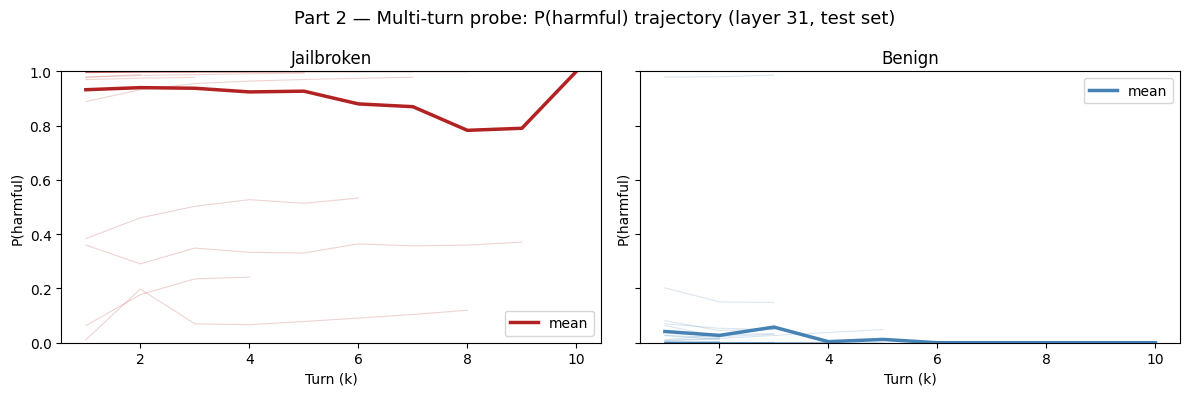

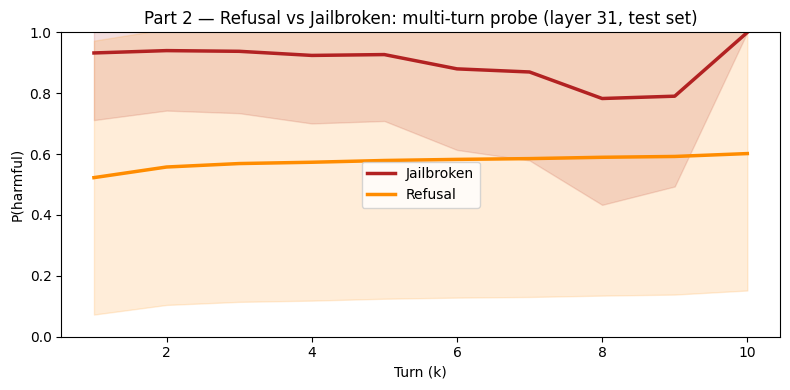

In [34]:
cr_layer_test = [r for r in reprs if r['layer'] == LAYER and r['id'] in test_ids
                 and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]

mt_jailbroken: dict[str, list] = defaultdict(list)
mt_benign:     dict[str, list] = defaultdict(list)
mt_refusal:    dict[str, list] = defaultdict(list)

for r in cr_layer_test:
    v = r['verdict']
    if v in ('Jailbroken', 'Near-Miss'): mt_jailbroken[r['id']].append(r)
    elif v == 'Benign':                  mt_benign[r['id']].append(r)
    elif v == 'Refusal':                 mt_refusal[r['id']].append(r)

for d in (mt_jailbroken, mt_benign, mt_refusal):
    for key in d: d[key].sort(key=lambda r: r['k'])

# Trajectory
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_traj(axes[0], mt_jailbroken, 'firebrick', 'Jailbroken', mt_p_harmful)
plot_traj(axes[1], mt_benign,     'steelblue', 'Benign',     mt_p_harmful)
fig.suptitle(f'Part 2 — Multi-turn probe: P(harmful) trajectory (layer {LAYER}, test set)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'mt_trajectory_l{LAYER}.png', dpi=150)
plt.show()

# Refusal vs Jailbroken
fig, ax = plt.subplots(figsize=(8, 4))
for traj_dict, color, label in [(mt_jailbroken, 'firebrick', 'Jailbroken'),
                                  (mt_refusal,    'darkorange', 'Refusal')]:
    if not traj_dict: continue
    all_scores = defaultdict(list)
    for records in traj_dict.values():
        for r in records:
            all_scores[r['k']].append(mt_p_harmful(get_cr_vec(r)))
    sorted_ks = sorted(all_scores)
    means = [np.mean(all_scores[k]) for k in sorted_ks]
    stds  = [np.std(all_scores[k])  for k in sorted_ks]
    ax.plot(sorted_ks, means, color=color, linewidth=2.5, label=label)
    ax.fill_between(sorted_ks, [m-s for m, s in zip(means, stds)],
                               [m+s for m, s in zip(means, stds)], color=color, alpha=0.15)
ax.set_ylim(0, 1); ax.set_xlabel('Turn (k)'); ax.set_ylabel('P(harmful)')
ax.set_title(f'Part 2 — Refusal vs Jailbroken: multi-turn probe (layer {LAYER}, test set)')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / f'mt_refusal_vs_jailbreak_l{LAYER}.png', dpi=150)
plt.show()

### 2b — Fixed-k probes: controlling for turn length

A probe trained on full-context representations is exposed to a distribution of context lengths: jailbroken conversations tend to have more turns on average because the attacker keeps escalating, while benign conversations plateau earlier since there is no harmful threshold to push past. This means the probe sees longer contexts for harmful examples than for benign ones on average, and could learn context length as a proxy for the label without learning anything about representation content.

To eliminate this confound, we train a separate probe at each turn depth using only conversations that reached exactly that many turns. Within each such probe, every training and test example has the same context length, so the separation cannot be explained by one class having longer conversations than the other. If these fixed-depth probes achieve high AUC across all turn depths, it means the separation is not driven by context length: the probe is detecting something already present at the very first turn that remains present regardless of how many turns are included. If AUC were to rise with depth, that would be evidence that the separating signal genuinely accumulates with Crescendo context. If AUC drops at high turn counts, that is typically because very few benign conversations reach those lengths, making the estimates unreliable — the sample size annotations in the plot indicate when this is the case.

In [35]:
MIN_TEST_PER_CLASS = 10
all_ks             = sorted(set(r['k'] for r in reprs if r['layer'] == LAYER))
fixed_k_results    = []

for k in all_ks:
    train_recs = [r for r in reprs if r['layer'] == LAYER and r['k'] == k
                  and r['id'] in train_ids and get_verdict_label(r) is not None
                  and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]
    test_recs  = [r for r in reprs if r['layer'] == LAYER and r['k'] == k
                  and r['id'] in test_ids and get_verdict_label(r) is not None
                  and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]

    y_tr = np.array([get_verdict_label(r) for r in train_recs])
    y_te = np.array([get_verdict_label(r) for r in test_recs])
    n_h, n_b = int((y_te == 1).sum()), int((y_te == 0).sum())

    if n_h < MIN_TEST_PER_CLASS or n_b < MIN_TEST_PER_CLASS or len(np.unique(y_tr)) < 2:
        print(f'  k={k:2d}  skip (test: h={n_h}, b={n_b})')
        continue

    X_tr = np.stack([get_cr_vec(r) for r in train_recs])
    X_te = np.stack([get_cr_vec(r) for r in test_recs])
    sc   = StandardScaler()
    sw   = compute_sample_weight('balanced', y_tr)
    clf  = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED)
    clf.fit(sc.fit_transform(X_tr), y_tr, sample_weight=sw)
    auc  = roc_auc_score(y_te, clf.predict_proba(sc.transform(X_te))[:, 1])

    fixed_k_results.append({'k': k, 'auc': auc, 'n_train': len(y_tr),
                             'n_test': len(y_te), 'n_h': n_h, 'n_b': n_b})
    print(f'  k={k:2d}  AUC={auc:.3f}  train={len(y_tr)}  test={len(y_te)} (h={n_h}, b={n_b})')

print(f'\n{len(fixed_k_results)} k values with sufficient test samples.')

  k= 1  AUC=0.992  train=437  test=110 (h=50, b=60)
  k= 2  AUC=0.994  train=387  test=100 (h=50, b=50)
  k= 3  AUC=0.987  train=269  test=70 (h=47, b=23)
  k= 4  AUC=0.989  train=165  test=48 (h=38, b=10)
  k= 5  skip (test: h=29, b=4)
  k= 6  skip (test: h=17, b=1)
  k= 7  skip (test: h=12, b=1)
  k= 8  skip (test: h=7, b=1)
  k= 9  skip (test: h=3, b=1)
  k=10  skip (test: h=2, b=1)

4 k values with sufficient test samples.


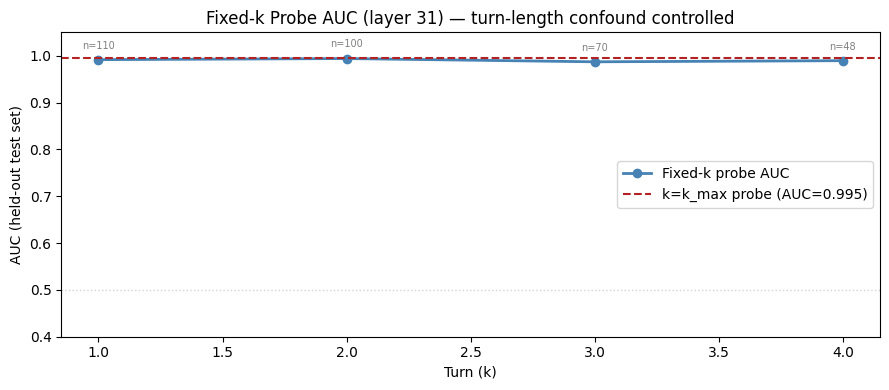

In [36]:
ks   = [r['k']      for r in fixed_k_results]
aucs = [r['auc']    for r in fixed_k_results]
ns   = [r['n_test'] for r in fixed_k_results]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, aucs, marker='o', color='steelblue', linewidth=2, label='Fixed-k probe AUC')
ax.axhline(mt_test_auc, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'k=k_max probe (AUC={mt_test_auc:.3f})')
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)
ax.set_ylim(0.4, 1.05)
ax.set_xlabel('Turn (k)'); ax.set_ylabel('AUC (held-out test set)')
ax.set_title(f'Fixed-k Probe AUC (layer {LAYER}) — turn-length confound controlled')
ax.legend()
for k, auc, n in zip(ks, aucs, ns):
    ax.annotate(f'n={n}', (k, auc), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'fixed_k_auc_l{LAYER}.png', dpi=150)
plt.show()

### 2c — Layer comparison

We repeat the multi-turn probe analysis at layer 20 using the same train/test split. The paper uses layer 31 for the original Llama model and layer 20 for the circuit breaker model, where the circuit breaker fine-tuning was applied. We use layer 31 as our primary layer throughout but include layer 20 as a check. If both layers produce similar AUC, the separating signal is robust across network depth and is not an artifact of a specific representational layer. If they diverge substantially, that would suggest the harmful/benign distinction is encoded at a particular depth rather than distributed throughout the network.

In [37]:
LAYER2      = 20
full_ctx2   = [r for r in reprs if r['layer'] == LAYER2 and r['k'] == r['k_max']
               and get_verdict_label(r) is not None
               and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]
train_ctx2  = [r for r in full_ctx2 if r['id'] in train_ids]
test_ctx2   = [r for r in full_ctx2 if r['id'] in test_ids]

X_tr2 = np.stack([get_cr_vec(r) for r in train_ctx2])
y_tr2 = np.array([get_verdict_label(r) for r in train_ctx2])
X_te2 = np.stack([get_cr_vec(r) for r in test_ctx2])
y_te2 = np.array([get_verdict_label(r) for r in test_ctx2])

sc2   = StandardScaler()
sw2   = compute_sample_weight('balanced', y_tr2)
clf2  = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=SEED)
clf2.fit(sc2.fit_transform(X_tr2), y_tr2, sample_weight=sw2)
auc2  = roc_auc_score(y_te2, clf2.predict_proba(sc2.transform(X_te2))[:, 1])

print(f'{"Metric":<35} {"L31":>8} {"L20":>8}')
print(f'{"Multi-turn probe AUC (test)":<35} {mt_test_auc:>8.3f} {auc2:>8.3f}')
print(f'{"Single-turn CV AUC (D_cb vs D_r)":<35} {np.mean(st_cv_aucs):>8.3f} {"—":>8}')

Metric                                   L31      L20
Multi-turn probe AUC (test)            0.995    0.996
Single-turn CV AUC (D_cb vs D_r)       0.999        —


---
## Part 3 — LAT reading vector (RepE methodology)

Parts 1 and 2 use supervised MLP probes: classifiers trained with outcome labels to learn a decision boundary. This part uses an unsupervised approach from the RepE framework (Zou et al., 2023): instead of training a classifier, we extract the direction in activation space that best captures the contrast between harmful and benign conditions using only the pairing structure of the dataset.

The procedure follows the function template from RepE. For each objective pair, the model is in two conditions: executing the harmful function (generating a harmful Crescendo response) and not executing it (generating a benign response on the paired objective). For each of the 98 pairs that have at least one jailbroken and one benign conversation, we compute the mean hidden state across all jailbroken conversations at full context and the mean hidden state across all benign conversations at full context. The difference between these two means — harmful minus benign — captures what changes between conditions for that pair. Averaging within each condition before taking the difference reduces conversation-specific noise.

We then run PCA on the 98 difference vectors. The first principal component is the reading vector — the single direction in the 4096-dimensional space that explains the most variance in how harmful and benign conditions differ across all pairs. Once we have this direction, any representation can be scored by projecting it onto the reading vector as a dot product. A higher score means the representation is further in the harmful direction; a lower score means it sits closer to benign.

This approach has two advantages over the MLP probe for measuring drift. First, the reading vector produces a continuous geometric score rather than a classification probability, so it does not saturate near the boundaries the way P(harmful) does. The MLP probe's output can be pinned near one across all turns with no room to show movement, while the projection onto the reading vector remains sensitive to small shifts in the underlying representation. Second, the reading vector is derived entirely from the pairing structure without using labels about which conversations are jailbroken or benign — it captures what changes between the two conditions across all pairs simultaneously, which is more robust to idiosyncratic features of individual conversations.

The final cell in this part computes per-conversation drift under both the MLP probe and the LAT projection for the held-out test set jailbroken conversations, and measures the Pearson correlation between them. If the two methods are measuring the same underlying representational change, the correlation should be high. If they are sensitive to different aspects of the geometry, the correlation will be low — and that divergence is itself informative about what each method captures.

In [38]:
from sklearn.decomposition import PCA
from collections import defaultdict

# --- Build difference vectors from paired conversations at k=k_max ---
pair_to_convs = defaultdict(list)
for cid, c in conversations.items():
    pair_to_convs[c['pair_idx']].append(c)

diff_vectors = []   # one per usable pair
pair_indices = []   # which pair_idx each diff_vector came from

for pidx, cs in sorted(pair_to_convs.items()):
    # Gather k=k_max representations for jailbroken and benign conversations
    jb_vecs, bn_vecs = [], []
    for c in cs:
        cid = c['id']
        # Find the k=k_max representation record for this conversation at PRIMARY_LAYER
        k_max_recs = [r for r in reprs
                      if r['id'] == cid and r['layer'] == PRIMARY_LAYER and r['k'] == r['k_max']
                      and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]
        if not k_max_recs:
            continue
        vec = get_cr_vec(k_max_recs[0])
        if c['verdict'] in ('Jailbroken', 'Near-Miss'):
            jb_vecs.append(vec)
        elif c['verdict'] == 'Benign':
            bn_vecs.append(vec)

    if not jb_vecs or not bn_vecs:
        continue  # skip pairs without both conditions

    h_pos = np.mean(jb_vecs, axis=0)  # A+f(i): mean over jailbroken runs
    h_neg = np.mean(bn_vecs, axis=0)  # A-f(i): mean over benign runs
    diff_vectors.append(h_pos - h_neg)
    pair_indices.append(pidx)

diff_matrix = np.stack(diff_vectors)  # (n_pairs, 4096)
print(f'Difference vectors: {diff_matrix.shape}  ({len(pair_indices)} pairs)')

# --- Fit PCA — first PC is the reading vector ---
pca = PCA(n_components=10)
pca.fit(diff_matrix)
reading_vector = pca.components_[0]  # (4096,) — the harmful generation direction
explained = pca.explained_variance_ratio_

print(f'Reading vector shape: {reading_vector.shape}')
print(f'Variance explained — PC1: {explained[0]:.3f}  PC2: {explained[1]:.3f}  PC3: {explained[2]:.3f}')
print(f'(RepE paper reports ~6.7% for PC1 on concept stimuli; function stimuli typically explain more)')

# Scalar projection helper
def lat_score(v: np.ndarray) -> float:
    """Project a hidden state onto the reading vector. Higher = more harmful."""
    return float(v @ reading_vector)

Difference vectors: (98, 4096)  (98 pairs)
Reading vector shape: (4096,)
Variance explained — PC1: 0.083  PC2: 0.070  PC3: 0.052
(RepE paper reports ~6.7% for PC1 on concept stimuli; function stimuli typically explain more)


LAT projection (layer 31):
  Jailbroken  k=1: 8.6784 ± 8.7563   k=kmax: 8.3915 ± 8.8018
  Benign      k=1: -2.0874 ± 6.3605   k=kmax: -2.2252 ± 6.4232

  Jailbroken drift (k=1 → kmax): +0.2869  ↓ decreases (consistent with paper)
  Benign     drift (k=1 → kmax): +0.1378


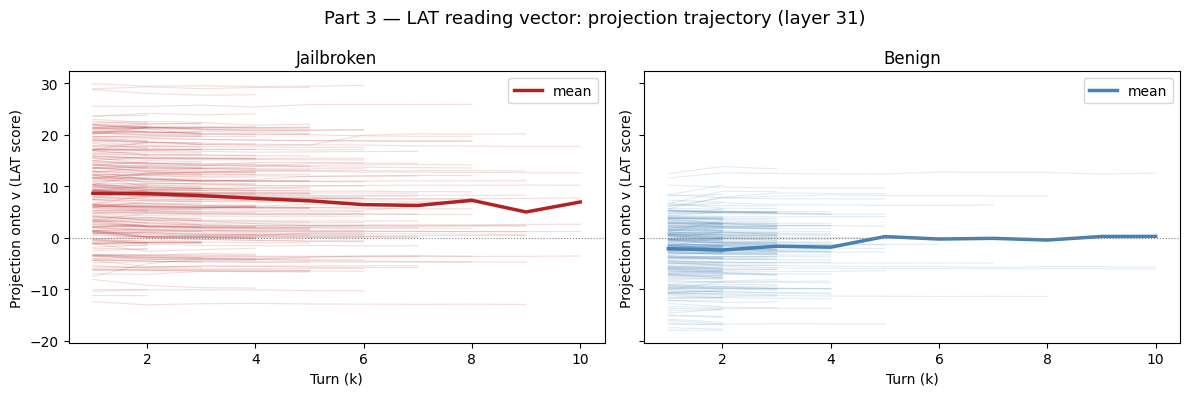

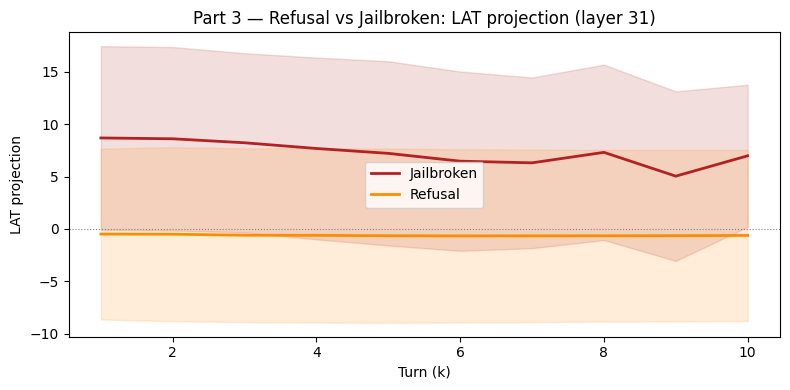

In [39]:
# --- Compute LAT trajectory: projection onto reading vector at each turn k ---
# Use ALL conversations (reading vector is unsupervised; no train/test split needed)
cr_layer_all_l31 = [r for r in reprs if r['layer'] == PRIMARY_LAYER
                    and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]

lat_jailbroken: dict[str, list] = defaultdict(list)
lat_benign:     dict[str, list] = defaultdict(list)
lat_refusal:    dict[str, list] = defaultdict(list)

for r in cr_layer_all_l31:
    score = lat_score(get_cr_vec(r))
    entry = {'k': r['k'], 'score': score, 'id': r['id']}
    v = r['verdict']
    if v in ('Jailbroken', 'Near-Miss'): lat_jailbroken[r['id']].append(entry)
    elif v == 'Benign':                  lat_benign[r['id']].append(entry)
    elif v == 'Refusal':                 lat_refusal[r['id']].append(entry)

for d in (lat_jailbroken, lat_benign, lat_refusal):
    for key in d: d[key].sort(key=lambda e: e['k'])

# Compute k=1 and k=kmax mean projections
def mean_at_k(traj_dict, k_selector):
    scores = [k_selector(entries)['score'] for entries in traj_dict.values() if entries]
    return np.mean(scores), np.std(scores)

jb_k1_mean,   jb_k1_std   = mean_at_k(lat_jailbroken, lambda e: min(e, key=lambda x: x['k']))
jb_kmax_mean, jb_kmax_std = mean_at_k(lat_jailbroken, lambda e: max(e, key=lambda x: x['k']))
bn_k1_mean,   bn_k1_std   = mean_at_k(lat_benign,     lambda e: min(e, key=lambda x: x['k']))
bn_kmax_mean, bn_kmax_std = mean_at_k(lat_benign,     lambda e: max(e, key=lambda x: x['k']))

print(f'LAT projection (layer {PRIMARY_LAYER}):')
print(f'  Jailbroken  k=1: {jb_k1_mean:.4f} ± {jb_k1_std:.4f}   k=kmax: {jb_kmax_mean:.4f} ± {jb_kmax_std:.4f}')
print(f'  Benign      k=1: {bn_k1_mean:.4f} ± {bn_k1_std:.4f}   k=kmax: {bn_kmax_mean:.4f} ± {bn_kmax_std:.4f}')

drift_jb = jb_k1_mean - jb_kmax_mean
drift_bn = bn_k1_mean - bn_kmax_mean
print(f'\n  Jailbroken drift (k=1 → kmax): {drift_jb:+.4f}  {"↓ decreases (consistent with paper)" if drift_jb > 0.01 else "↑ increases" if drift_jb < -0.01 else "≈ flat"}')
print(f'  Benign     drift (k=1 → kmax): {drift_bn:+.4f}')

# --- Plot: LAT projection trajectory ---
def plot_lat_traj(ax, traj_dict, color, title):
    all_scores = defaultdict(list)
    for entries in traj_dict.values():
        ks     = [e['k']     for e in entries]
        scores = [e['score'] for e in entries]
        ax.plot(ks, scores, color=color, alpha=0.15, linewidth=0.8)
        for k, s in zip(ks, scores):
            all_scores[k].append(s)
    sorted_ks = sorted(all_scores)
    means = [np.mean(all_scores[k]) for k in sorted_ks]
    ax.plot(sorted_ks, means, color=color, linewidth=2.5, label='mean')
    ax.set_xlabel('Turn (k)')
    ax.set_ylabel('Projection onto v (LAT score)')
    ax.set_title(title)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_lat_traj(axes[0], lat_jailbroken, 'firebrick', 'Jailbroken')
plot_lat_traj(axes[1], lat_benign,     'steelblue', 'Benign')
fig.suptitle(f'Part 3 — LAT reading vector: projection trajectory (layer {PRIMARY_LAYER})', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'lat_trajectory_l{PRIMARY_LAYER}.png', dpi=150)
plt.show()

# --- Refusal vs Jailbroken ---
fig, ax = plt.subplots(figsize=(8, 4))
for traj_dict, color, label in [(lat_jailbroken, 'firebrick', 'Jailbroken'),
                                  (lat_refusal,    'darkorange', 'Refusal')]:
    all_scores = defaultdict(list)
    for entries in traj_dict.values():
        for e in entries:
            all_scores[e['k']].append(e['score'])
    sorted_ks = sorted(all_scores)
    means = [np.mean(all_scores[k]) for k in sorted_ks]
    sds   = [np.std(all_scores[k])  for k in sorted_ks]
    ax.plot(sorted_ks, means, color=color, linewidth=2, label=label)
    ax.fill_between(sorted_ks,
                    [m - s for m, s in zip(means, sds)],
                    [m + s for m, s in zip(means, sds)],
                    color=color, alpha=0.15)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Turn (k)'); ax.set_ylabel('LAT projection')
ax.set_title(f'Part 3 — Refusal vs Jailbroken: LAT projection (layer {PRIMARY_LAYER})')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'lat_refusal_vs_jailbreak_l{PRIMARY_LAYER}.png', dpi=150)
plt.show()

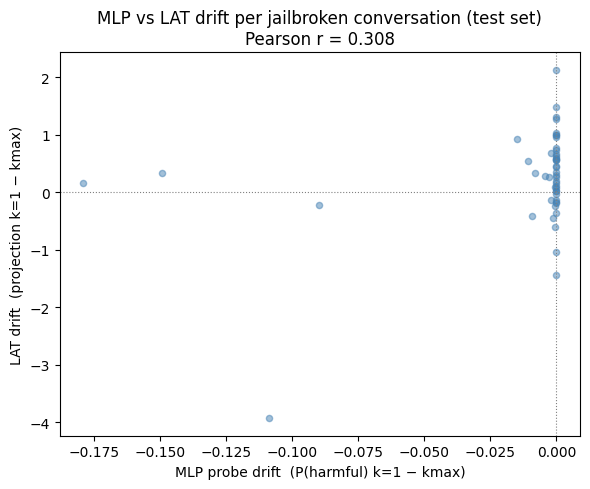

MLP drift — mean: -0.0117  std: 0.0369
LAT drift — mean: 0.2337  std: 0.8599
Pearson r (MLP vs LAT drift): 0.308
→ Weak agreement: partial overlap between MLP boundary and LAT direction.


In [40]:
# --- Compare MLP probe vs LAT: do they tell the same story? ---
# Compute per-conversation mean drift for both methods (test set jailbroken conversations only)
# Drift = score at k=1 minus score at k=kmax  (positive = decreasing toward benign)

mlp_drifts = []
lat_drifts  = []

for cid, entries in lat_jailbroken.items():
    if cid not in test_ids:
        continue
    entries_sorted = sorted(entries, key=lambda e: e['k'])
    k1_recs   = [r for r in reprs if r['id'] == cid and r['layer'] == PRIMARY_LAYER and r['k'] == 1
                 and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]
    kmax_recs = [r for r in reprs if r['id'] == cid and r['layer'] == PRIMARY_LAYER and r['k'] == r['k_max']
                 and str(CRESCENDO_DIR / r['mean_pooled_path']) in cr_cache]
    if not k1_recs or not kmax_recs:
        continue

    mlp_k1   = mt_p_harmful(get_cr_vec(k1_recs[0]))
    mlp_kmax = mt_p_harmful(get_cr_vec(kmax_recs[0]))
    lat_k1   = lat_score(get_cr_vec(k1_recs[0]))
    lat_kmax = lat_score(get_cr_vec(kmax_recs[0]))

    mlp_drifts.append(mlp_k1 - mlp_kmax)
    lat_drifts.append(lat_k1 - lat_kmax)

mlp_drifts = np.array(mlp_drifts)
lat_drifts  = np.array(lat_drifts)

# Correlation between the two drift measures
corr = np.corrcoef(mlp_drifts, lat_drifts)[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mlp_drifts, lat_drifts, alpha=0.5, s=20, color='steelblue')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('MLP probe drift  (P(harmful) k=1 − kmax)')
ax.set_ylabel('LAT drift  (projection k=1 − kmax)')
ax.set_title(f'MLP vs LAT drift per jailbroken conversation (test set)\nPearson r = {corr:.3f}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'mlp_vs_lat_drift_l{PRIMARY_LAYER}.png', dpi=150)
plt.show()

print(f'MLP drift — mean: {mlp_drifts.mean():.4f}  std: {mlp_drifts.std():.4f}')
print(f'LAT drift — mean: {lat_drifts.mean():.4f}  std: {lat_drifts.std():.4f}')
print(f'Pearson r (MLP vs LAT drift): {corr:.3f}')
if corr > 0.5:
    print('→ Both methods agree: same conversations drift in the same direction.')
elif corr < 0.2:
    print('→ Methods disagree: MLP and LAT are capturing different signals.')
else:
    print('→ Weak agreement: partial overlap between MLP boundary and LAT direction.')